In [24]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

def extract_soh_curve(mat_file_path):
    data = loadmat(mat_file_path)
    data_cell = data['data_cell']
    num_cycles = data_cell.shape[1]
    capacities = []
    for i in range(num_cycles):
        cycle = data_cell[0, i]
        fields = cycle.dtype.names
        # Group 1 style
        if 'dischg_Capacity_mAh' in fields:
            dischg_capacity = cycle['dischg_Capacity_mAh'][0,0]
        # Group 2/3/4 style
        elif 'dischg_Capacity_Ah' in fields:
            dischg_capacity = cycle['dischg_Capacity_Ah'][0,0]
            # convert Ah → mAh
            dischg_capacity = dischg_capacity * 1000
        else:
            continue
        final_capacity = dischg_capacity[-1,0]
        capacities.append(final_capacity)
    capacities = np.array(capacities)
    capacities = capacities[~np.isnan(capacities)]
    reference_capacity = np.max(capacities)
    soh = capacities / reference_capacity
    return soh


In [2]:
data = loadmat("../data/raw/Group 1/G1_Cell1_Data.mat")

In [3]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_cell'])


In [4]:
print(type(data['data_cell']))
print(data['data_cell'].shape)

<class 'numpy.ndarray'>
(1, 612)


In [5]:
cycle1 = data['data_cell'][0,0]

In [6]:
print(type(cycle1))
print(cycle1.dtype)

<class 'numpy.ndarray'>
[('chg_Time_s', 'O'), ('chg_Voltage_V', 'O'), ('chg_Current_mA', 'O'), ('chg_Capacity_mAh', 'O'), ('chg_StepID', 'O'), ('dischg_Time_s', 'O'), ('dischg_Voltage_V', 'O'), ('dischg_Current_mA', 'O'), ('dischg_Capacity_mAh', 'O'), ('dischg_StepID', 'O'), ('fullCycle_Time_s', 'O'), ('fullCycle_Voltage_V', 'O'), ('fullCycle_Current_mA', 'O'), ('fullCycle_StepID', 'O'), ('fullCycle_SoC', 'O')]


In [7]:
chg_voltage = cycle1['chg_Voltage_V'][0,0]
chg_time = cycle1['chg_Time_s'][0,0]
print(chg_voltage.shape)
print(chg_time.shape)

(642, 1)
(642, 1)


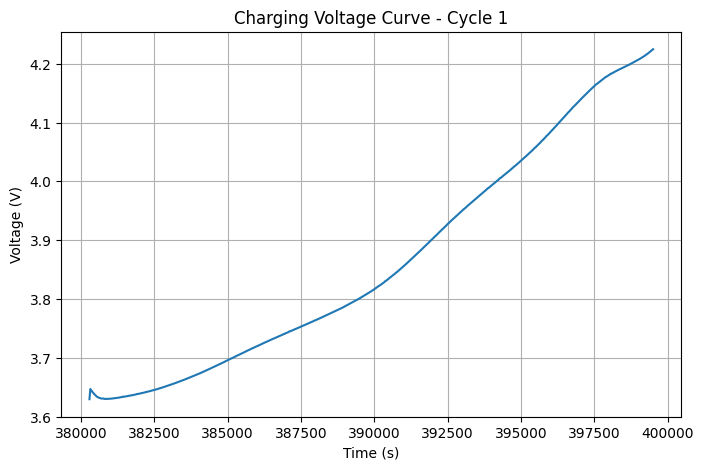

In [8]:
plt.figure(figsize=(8,5))
plt.plot(chg_time, chg_voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Charging Voltage Curve - Cycle 1")
plt.grid(True)
plt.show()

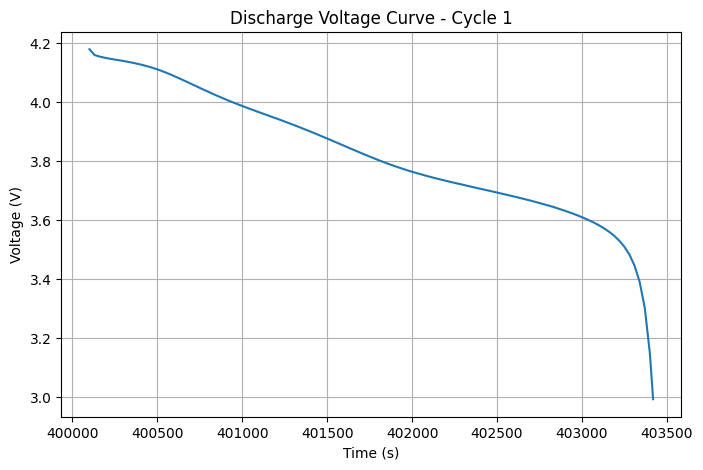

In [9]:
dischg_voltage = cycle1['dischg_Voltage_V'][0,0]
dischg_time = cycle1['dischg_Time_s'][0,0]

plt.figure(figsize=(8,5))

plt.plot(dischg_time, dischg_voltage)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Discharge Voltage Curve - Cycle 1")

plt.grid(True)
plt.show()

In [10]:
dischg_capacity = cycle1['dischg_Capacity_mAh'][0,0]
chg_capacity = cycle1['chg_Capacity_mAh'][0,0]

print(dischg_capacity.shape)
print(chg_capacity.shape)

print(dischg_capacity[:5])

(112, 1)
(642, 1)
[[-0.        ]
 [ 0.03118333]
 [ 0.06236667]
 [ 0.09355   ]
 [ 0.12473333]]


In [11]:
final_capacity = dischg_capacity[-1,0]
print("Final discharge capacity:",final_capacity,"mAh")

Final discharge capacity: 3.4502661111111292 mAh


In [12]:
num_cycles = data['data_cell'].shape[1]
capacities = []
for i in range(num_cycles):
    cycle = data['data_cell'][0,i]
    dischg_capacity = cycle['dischg_Capacity_mAh'][0,0]
    final_capacity = dischg_capacity[-1,0]
    capacities.append(final_capacity)
print("Number of cycles:",len(capacities))
print("First 5 capacities:")
print(capacities[:5]) 

Number of cycles: 612
First 5 capacities:
[np.float64(3.4502661111111292), np.float64(3.706767499999983), np.float64(3.8396233333333396), np.float64(3.782258055555597), np.float64(3.72737666666658)]


In [13]:
cycles = np.arrange(1,num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles,capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

AttributeError: module 'numpy' has no attribute 'arrange'

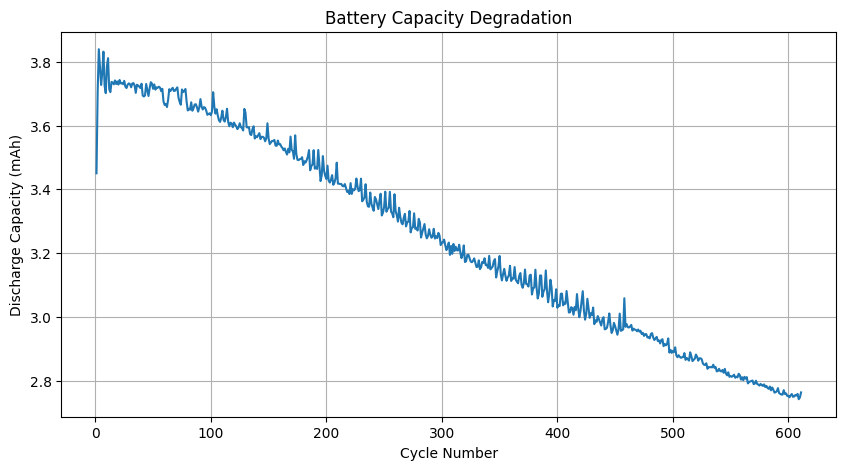

In [14]:
cycles = np.arange(1, num_cycles + 1)
plt.figure(figsize=(10,5))
plt.plot(cycles, capacities)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (mAh)")
plt.title("Battery Capacity Degradation")
plt.grid(True)
plt.show()

In [15]:
initial_capacity = capacities[0]

soh = np.array(capacities) / initial_capacity

print("First 5 SOH values:")
print(soh[:5])

First 5 SOH values:
[1.         1.07434249 1.11284846 1.09622213 1.08031571]


In [16]:
reference_capacity = max(capacities)

soh = np.array(capacities) / reference_capacity

print("Reference capacity:", reference_capacity)

print("First 5 SOH values:")
print(soh[:5])

Reference capacity: 3.8396233333333396
First 5 SOH values:
[0.89859494 0.96539873 1.         0.98505966 0.97076623]


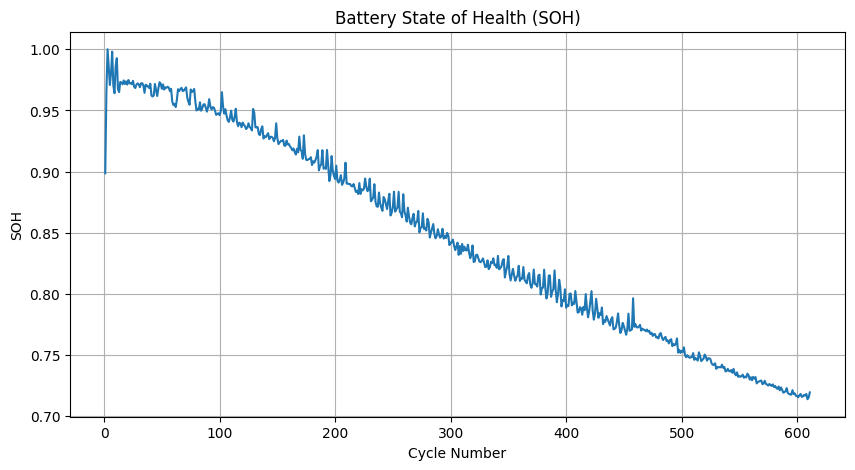

In [17]:
plt.figure(figsize=(10,5))

plt.plot(cycles, soh)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Battery State of Health (SOH)")

plt.grid(True)
plt.show()

In [3]:
capacities = extract_capacity_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(capacities[:5])
print("Total cycles:", len(capacities))

[3.45026611 3.7067675  3.83962333 3.78225806 3.72737667]
Total cycles: 612


In [7]:
soh = extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(soh[:5])
print("Total Cycles:",len(soh))

[nan nan nan nan nan]
Total Cycles: 612


In [8]:
print(np.isnan(capacities).sum())

1


In [9]:
print(capacities[:20])

[3.45026611 3.7067675  3.83962333 3.78225806 3.72737667 3.76534889
 3.83196722 3.72557361 3.70173806 3.78600694 3.81159167 3.7147625
 3.70492389 3.73690417 3.73504028 3.72946194 3.74163194 3.73046042
 3.73856306 3.72864444]


In [11]:
soh =  extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)
print(soh[:5])
print("Total cycles:",len(soh))

[0.89859494 0.96539873 1.         0.98505966 0.97076623]
Total cycles: 611


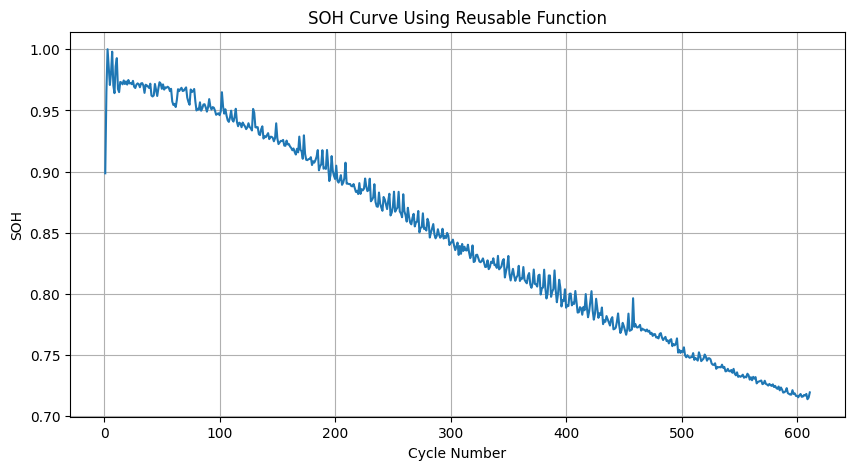

In [13]:
soh = extract_soh_curve(
    "../data/raw/Group 1/G1_Cell1_Data.mat"
)

cycles = np.arange(1, len(soh) + 1)

plt.figure(figsize=(10,5))

plt.plot(cycles, soh)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("SOH Curve Using Reusable Function")

plt.grid(True)
plt.show()

In [15]:
group1_files = glob.glob("../data/raw/Group 1/*Data.mat")
print("Number of files:",len(group1_files))
print("\nFIles found:")
for file in group1_files:
    print(file)


Number of files: 6

FIles found:
../data/raw/Group 1\G1_Cell1_Data.mat
../data/raw/Group 1\G1_Cell2_Data.mat
../data/raw/Group 1\G1_Cell3_Data.mat
../data/raw/Group 1\G1_Cell4_Data.mat
../data/raw/Group 1\G1_Cell5_Data.mat
../data/raw/Group 1\G1_Cell6_Data.mat


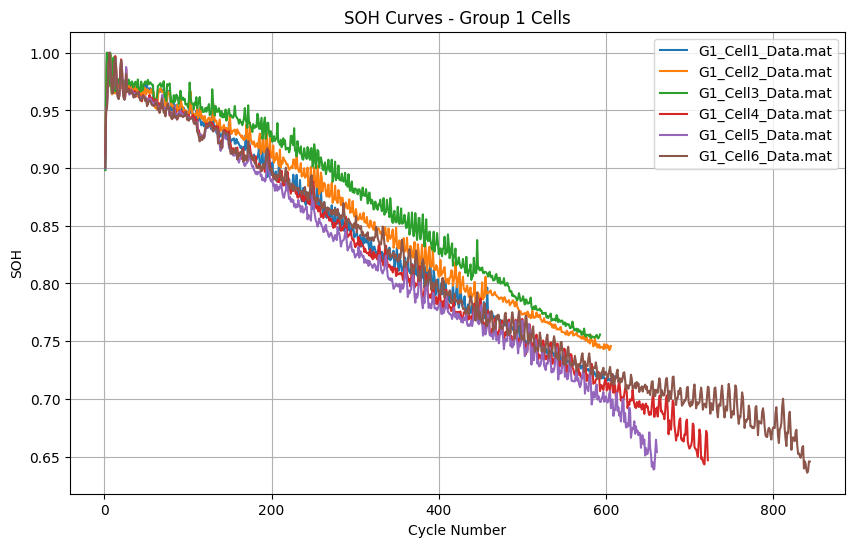

In [16]:
plt.figure(figsize=(10,6))
for file in group1_files:
    soh = extract_soh_curve(file)
    cycles = np.arange(1, len(soh) + 1)
    file_name = file.split("\\")[-1]
    plt.plot(cycles, soh, label=file_name)

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("SOH Curves - Group 1 Cells")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
all_data = []

In [18]:
for file in group1_files:
    soh = extract_soh_curve(file)
    file_name = file.split("\\")[-1]
    cell_name = file_name.replace("_Data.mat","")
    for cycle_num, soh_value in enumerate(soh, start=1):
        all_data.append({
            "group" : 1,
            "cell": cell_name,
            "cycle":cycle_num,
            "soh":soh_value
        })

In [19]:
df = pd.DataFrame(all_data)
df.head()

,group,cell,cycle,soh
0,1,G1_Cell1,1,0.898595
1,1,G1_Cell1,2,0.965399
2,1,G1_Cell1,3,1.000000
3,1,G1_Cell1,4,0.985060
4,1,G1_Cell1,5,0.970766


In [20]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"Group {group_num}: {len(group_files)} files")

    for file in group_files:

        soh = extract_soh_curve(file)

        file_name = file.split("\\")[-1]

        cell_name = file_name.replace("_Data.mat", "")

        for cycle_num, soh_value in enumerate(soh, start=1):

            all_data.append({
                "group": group_num,
                "cell": cell_name,
                "cycle": cycle_num,
                "soh": soh_value
            })

Group 1: 6 files
Group 2: 5 files


ValueError: no field of name dischg_Capacity_mAh

In [21]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"\nGroup {group_num}: {len(group_files)} files")

    for file in group_files:

        print("Processing:", file)

        soh = extract_soh_curve(file)


Group 1: 6 files
Processing: ../data/raw/Group 1\G1_Cell1_Data.mat
Processing: ../data/raw/Group 1\G1_Cell2_Data.mat
Processing: ../data/raw/Group 1\G1_Cell3_Data.mat
Processing: ../data/raw/Group 1\G1_Cell4_Data.mat
Processing: ../data/raw/Group 1\G1_Cell5_Data.mat
Processing: ../data/raw/Group 1\G1_Cell6_Data.mat

Group 2: 5 files
Processing: ../data/raw/Group 2\G2_Cell1_Data.mat


ValueError: no field of name dischg_Capacity_mAh

In [22]:
g2_data = loadmat("../data/raw/Group 2/G2_Cell1_Data.mat")

print(g2_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data_cell'])


In [23]:
g2_cycle1 = g2_data['data_cell'][0,0]

print(g2_cycle1.dtype)

[('chg_Time_s', 'O'), ('chg_Voltage_V', 'O'), ('chg_Current_A', 'O'), ('chg_Capacity_Ah', 'O'), ('chg_StepID', 'O'), ('dischg_Time_s', 'O'), ('dischg_Voltage_V', 'O'), ('dischg_Current_A', 'O'), ('dischg_Capacity_Ah', 'O'), ('dischg_StepID', 'O'), ('fullCycle_Time_s', 'O'), ('fullCycle_Voltage_V', 'O'), ('fullCycle_Current_A', 'O'), ('fullCycle_StepID', 'O'), ('fullCycle_SoC', 'O')]


In [25]:
soh = extract_soh_curve(
    "../data/raw/Group 2/G2_Cell1_Data.mat"
)

print(soh[:5])
print(len(soh))

[0.95410604 0.94427329 0.90894827 0.89200956 0.97747764]
528


In [26]:
all_data = []

for group_num in range(1, 5):

    pattern = f"../data/raw/Group {group_num}/*Data.mat"

    group_files = glob.glob(pattern)

    print(f"\nGroup {group_num}: {len(group_files)} files")

    for file in group_files:

        print("Processing:", file)

        soh = extract_soh_curve(file)

        file_name = file.split("\\")[-1]

        cell_name = file_name.replace("_Data.mat", "")

        for cycle_num, soh_value in enumerate(soh, start=1):

            all_data.append({
                "group": group_num,
                "cell": cell_name,
                "cycle": cycle_num,
                "soh": soh_value
            })


Group 1: 6 files
Processing: ../data/raw/Group 1\G1_Cell1_Data.mat
Processing: ../data/raw/Group 1\G1_Cell2_Data.mat
Processing: ../data/raw/Group 1\G1_Cell3_Data.mat
Processing: ../data/raw/Group 1\G1_Cell4_Data.mat
Processing: ../data/raw/Group 1\G1_Cell5_Data.mat
Processing: ../data/raw/Group 1\G1_Cell6_Data.mat

Group 2: 5 files
Processing: ../data/raw/Group 2\G2_Cell1_Data.mat
Processing: ../data/raw/Group 2\G2_Cell2_Data.mat
Processing: ../data/raw/Group 2\G2_Cell3_Data.mat
Processing: ../data/raw/Group 2\G2_Cell4_Data.mat
Processing: ../data/raw/Group 2\G2_Cell5_Data.mat

Group 3: 7 files
Processing: ../data/raw/Group 3\G3_Cell1_Data.mat
Processing: ../data/raw/Group 3\G3_Cell2_Data.mat
Processing: ../data/raw/Group 3\G3_Cell3_Data.mat
Processing: ../data/raw/Group 3\G3_Cell4_Data.mat
Processing: ../data/raw/Group 3\G3_Cell5_Data.mat
Processing: ../data/raw/Group 3\G3_Cell6_Data.mat
Processing: ../data/raw/Group 3\G3_Cell7_Data.mat

Group 4: 5 files
Processing: ../data/raw/Grou

In [27]:
df = pd.DataFrame(all_data)

print(df.shape)

df.head()


(11005, 4)


,group,cell,cycle,soh
0,1,G1_Cell1,1,0.898595
1,1,G1_Cell1,2,0.965399
2,1,G1_Cell1,3,1.000000
3,1,G1_Cell1,4,0.985060
4,1,G1_Cell1,5,0.970766


In [28]:
print(df.shape)

(11005, 4)


In [35]:
X = []
y = []

In [34]:
window_size = 10

In [36]:
for cell_name in df['cell'].unique():

    cell_df = df[df['cell'] == cell_name]

    soh_values = cell_df['soh'].values

    for i in range(len(soh_values) - window_size):

        input_window = soh_values[i:i+window_size]

        target = soh_values[i+window_size]

        X.append(input_window)

        y.append(target)

In [37]:
X = np.array(X)

y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10775, 10)
y shape: (10775,)


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8620, 10)
Testing samples: (2155, 10)


In [41]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.98994267 0.80817789 0.96635457 0.95573071 0.96508228]


In [43]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 0.0036017438384140124
RMSE: 0.005307228977607188


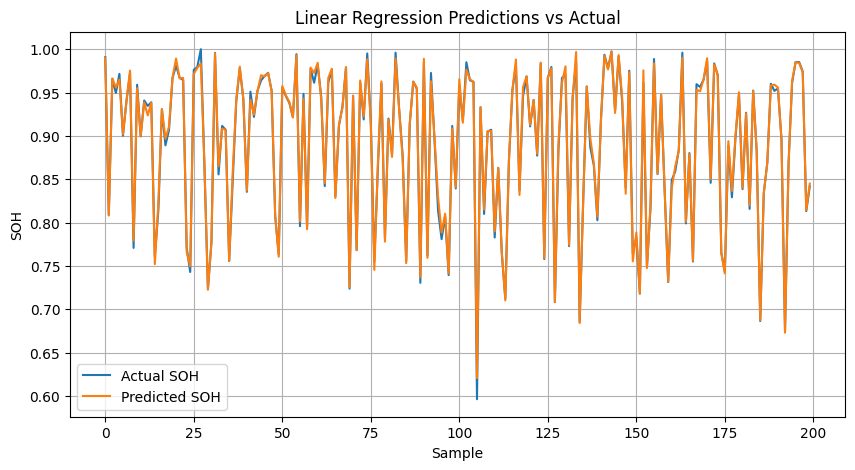

In [44]:
plt.figure(figsize=(10,5))

plt.plot(y_test[:200], label="Actual SOH")

plt.plot(y_pred[:200], label="Predicted SOH")

plt.xlabel("Sample")

plt.ylabel("SOH")

plt.title("Linear Regression Predictions vs Actual")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [48]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [49]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:5])

[0.98832784 0.80814487 0.96589639 0.95177798 0.9653646 ]


In [50]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 0.0029675414691063312
Random Forest RMSE: 0.004466125962365969


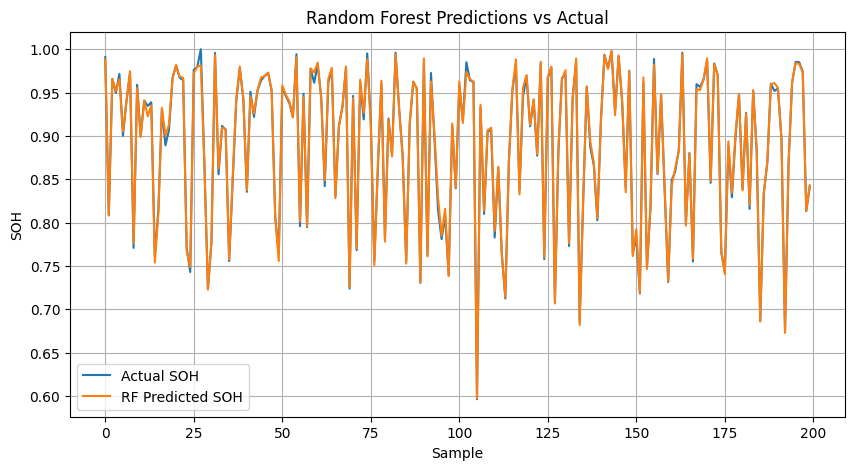

In [51]:
plt.figure(figsize=(10,5))

plt.plot(y_test[:200], label="Actual SOH")

plt.plot(rf_pred[:200], label="RF Predicted SOH")

plt.xlabel("Sample")

plt.ylabel("SOH")

plt.title("Random Forest Predictions vs Actual")

plt.legend()

plt.grid(True)

plt.show()

In [53]:
from xgboost import XGBRegressor 

In [54]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [55]:
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [56]:
xgb_pred = xgb_model.predict(X_test)

print(xgb_pred[:5])

[0.9890621  0.8099803  0.963861   0.95184183 0.9652418 ]


In [57]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", xgb_mae)

print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 0.0032821463439585527
XGBoost RMSE: 0.004839743358663507
